In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import math

In [25]:
np.random.seed(42)
tf.random.set_seed(42)

In [27]:
dataset = pd.read_csv('rnn_time_series_dataset.csv')

In [29]:
dataset.head()

,datetime,hour,day_of_week,is_weekend,temperature,promotion,holiday,energy_demand
0,2025-01-01 00:00:00,0,2,0,25.745071,1,0,276.579331
1,2025-01-01 01:00:00,1,2,0,27.388066,0,0,246.640997
2,2025-01-01 02:00:00,2,2,0,30.986077,0,0,230.457803
3,2025-01-01 03:00:00,3,2,0,34.377429,0,0,256.852672
4,2025-01-01 04:00:00,4,2,0,33.338113,0,0,264.043859


In [51]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [53]:
data = dataset.values  
data

array([[  0.        ,   2.        ,  25.74507123, 276.5793314 ],
       [  1.        ,   2.        ,  27.3880662 , 246.64099725],
       [  2.        ,   2.        ,  30.9860772 , 230.45780276],
       ...,
       [ 21.        ,   6.        ,  19.59897913, 202.97304244],
       [ 22.        ,   6.        ,  20.21719611, 246.58790505],
       [ 23.        ,   6.        ,  21.89970846, 247.65606271]])

In [55]:
train_size = int(0.8 * len(data))
test_size = len(data) - train_size
train_data, test_data = data[:train_size], data[train_size:]

In [57]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data)  #  Fit only on training
test_data_scaled = scaler.transform(test_data)  # Transform only on test set

In [59]:
val_size = int(0.1 * len(train_data_scaled))  # 10% of training for validation
train_data_final, val_data = train_data_scaled[:-val_size], train_data_scaled[-val_size:]

In [61]:
def create_sequences(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, 0])  # Assuming the first feature is the target
    return np.array(X), np.array(y)

time_step = 10  # You can adjust this value

In [63]:
X_train, y_train = create_sequences(train_data_final, time_step)
X_val, y_val = create_sequences(val_data, time_step)
X_test, y_test = create_sequences(test_data_scaled, time_step)

In [65]:
print(f'X_train >>> {X_train.shape} ---- y_train >> {y_train.shape}')
print(f'X_val >>> {X_val.shape} ----- y_val >> {y_val.shape}')
print(f'X_test >>> {X_test.shape} ----- y_test >> {y_test.shape}')

X_train >>> (3101, 10, 4) ---- y_train >> (3101,)
X_val >>> (335, 10, 4) ----- y_val >> (335,)
X_test >>> (854, 10, 4) ----- y_test >> (854,)


In [67]:
print(train_data_final.shape, val_data.shape, test_data_scaled.shape)

(3111, 4) (345, 4) (864, 4)


In [69]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(3101, 10, 4) (3101,)
(335, 10, 4) (335,)
(854, 10, 4) (854,)


In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

In [83]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(10, 4)),  # First LSTM layer
    LSTM(50, return_sequences=False),  # Second LSTM layer
    Dense(25, activation='relu'),  # Dense hidden layer
    Dense(1)  # Output layer (regression)
])

C:\Users\12146\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [85]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [77]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 10, 50)              │          10,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,301 (126.18 KB)

 Trainable params: 32,301 (126.18 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0710 - mae: 0.2030 - val_loss: 0.0652 - val_mae: 0.1741
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0280 - mae: 0.0998 - val_loss: 0.0731 - val_mae: 0.1430
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0216 - mae: 0.0789 - val_loss: 0.0574 - val_mae: 0.1072
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0195 - mae: 0.0755 - val_loss: 0.0407 - val_mae: 0.0848
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0175 - mae: 0.0695 - val_loss: 0.0306 - val_mae: 0.0774
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0154 - mae: 0.0636 - val_loss: 0.0253 - val_mae: 0.0749
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0134 - mae: 0.0567 - val_loss: 0.0234 - val_mae: 0.0729
Epoch 8/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0117 - mae: 0.0502 - val_loss: 0.0210 - val_mae: 0.0660
Epoch 9/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0105

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

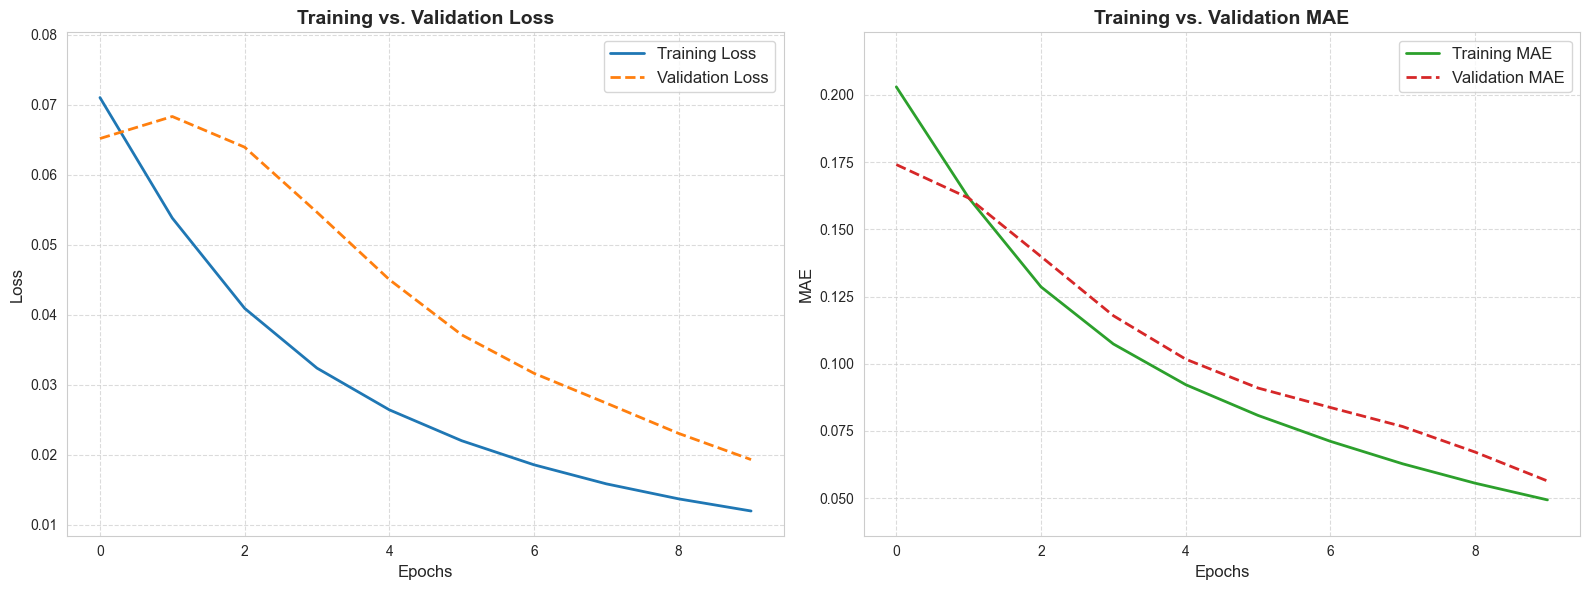

In [91]:
# Apply Seaborn theme for a more professional look
sns.set_style("whitegrid")

# Function to apply moving average smoothing
def smooth_curve(values, smoothing=0.6):
    smoothed_values = []
    prev = values[0]  # Start with the first value
    for v in values:
        smoothed_val = prev * smoothing + v * (1 - smoothing)
        smoothed_values.append(smoothed_val)
        prev = smoothed_val
    return smoothed_values
# Extract loss and MAE data from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_mae = history.history['mae']
val_mae = history.history['val_mae']

# Smooth the curves for better visualization
train_loss_smooth = smooth_curve(train_loss, 0.6)
val_loss_smooth = smooth_curve(val_loss, 0.6)
train_mae_smooth = smooth_curve(train_mae, 0.6)
val_mae_smooth = smooth_curve(val_mae, 0.6)

# Create subplots for Loss and MAE
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training & Validation Loss
axs[0].plot(train_loss_smooth, label='Training Loss', color='#1f77b4', linewidth=2)
axs[0].plot(val_loss_smooth, label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='dashed')
axs[0].set_title('Training vs. Validation Loss', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Epochs', fontsize=12)
axs[0].set_ylabel('Loss', fontsize=12)
axs[0].legend(fontsize=12, loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].set_ylim(min(min(train_loss), min(val_loss)) * 0.9, max(max(train_loss), max(val_loss)) * 1.1)

# Plot 2: Training & Validation MAE
axs[1].plot(train_mae_smooth, label='Training MAE', color='#2ca02c', linewidth=2)
axs[1].plot(val_mae_smooth, label='Validation MAE', color='#d62728', linewidth=2, linestyle='dashed')
axs[1].set_title('Training vs. Validation MAE', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Epochs', fontsize=12)
axs[1].set_ylabel('MAE', fontsize=12)
axs[1].legend(fontsize=12, loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].set_ylim(min(min(train_mae), min(val_mae)) * 0.9, max(max(train_mae), max(val_mae)) * 1.1)

# Improve layout
plt.tight_layout()
plt.show()

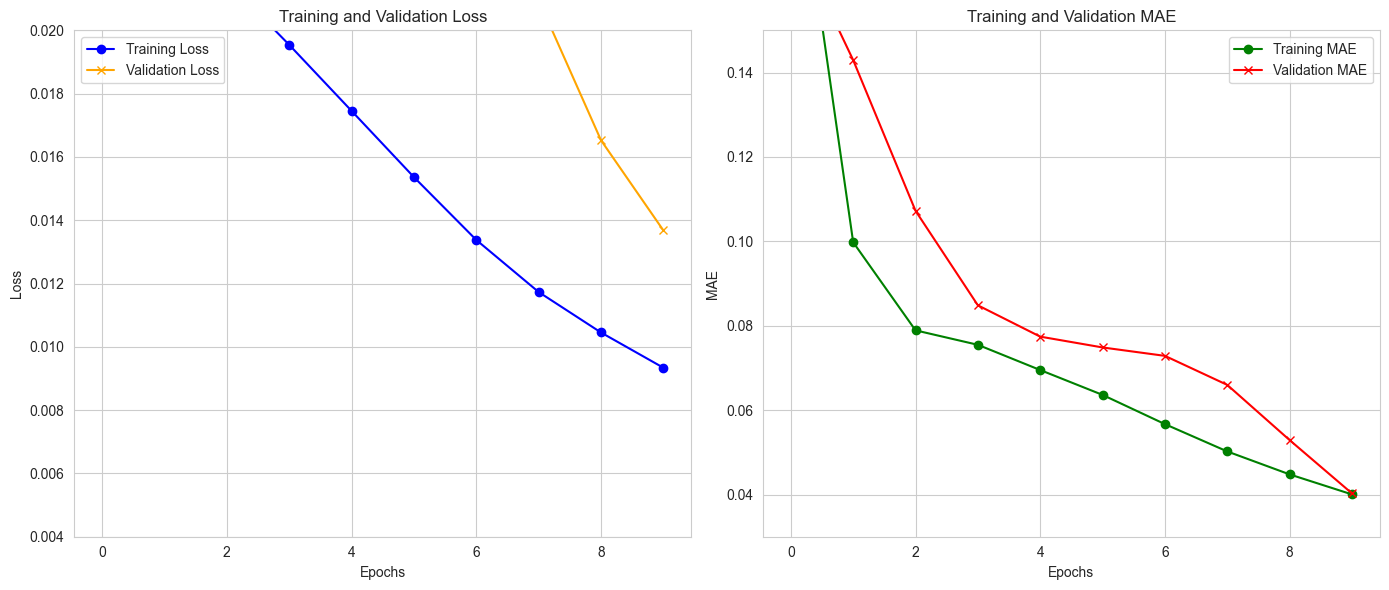

In [95]:
import matplotlib.pyplot as plt

# Create subplots for Loss and MAE
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot training & validation loss
axs[0].plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
axs[0].plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='x')
axs[0].set_title('Training and Validation Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)
axs[0].set_ylim(0.004, 0.020)  # Set y-axis range

# Plot training & validation MAE
axs[1].plot(history.history['mae'], label='Training MAE', color='green', marker='o')
axs[1].plot(history.history['val_mae'], label='Validation MAE', color='red', marker='x')
axs[1].set_title('Training and Validation MAE')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('MAE')
axs[1].legend()
axs[1].grid(True)
axs[1].set_ylim(0.03, 0.15)  # Set y-axis range

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [97]:
y_pred = model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [99]:
print(y_pred.shape)  # Should match y_test.shape (e.g., (10096, 1))

(854, 1)


In [101]:
y_pred = y_pred.flatten()
y_pred.shape

(854,)

In [105]:
# Ensure scaled_data is properly defined before using its shape
num_features = 4  # Update this based on your dataset

# Create a full array for inverse transformation
y_pred_full = np.zeros((y_pred.shape[0], num_features))  # Use the same number of features as original data
y_pred_full[:, 0] = y_pred.flatten()  # Insert predictions into the first column

# Apply inverse transformation
y_pred_inverse = scaler.inverse_transform(y_pred_full)[:, 0]  # Extract only the first column

# If y_test was also scaled, inverse transform it for comparison
y_test_full = np.zeros((y_test.shape[0], num_features))  # Use the same number of features
y_test_full[:, 0] = y_test.flatten()
y_test_inverse = scaler.inverse_transform(y_test_full)[:, 0]  # Extract only the first column

In [107]:
from sklearn.metrics import r2_score

# Compute R² score
r2 = r2_score(y_test_inverse, y_pred_inverse)

# Print the R² score
print("R² Score:", r2)

R² Score: 0.846142692013828


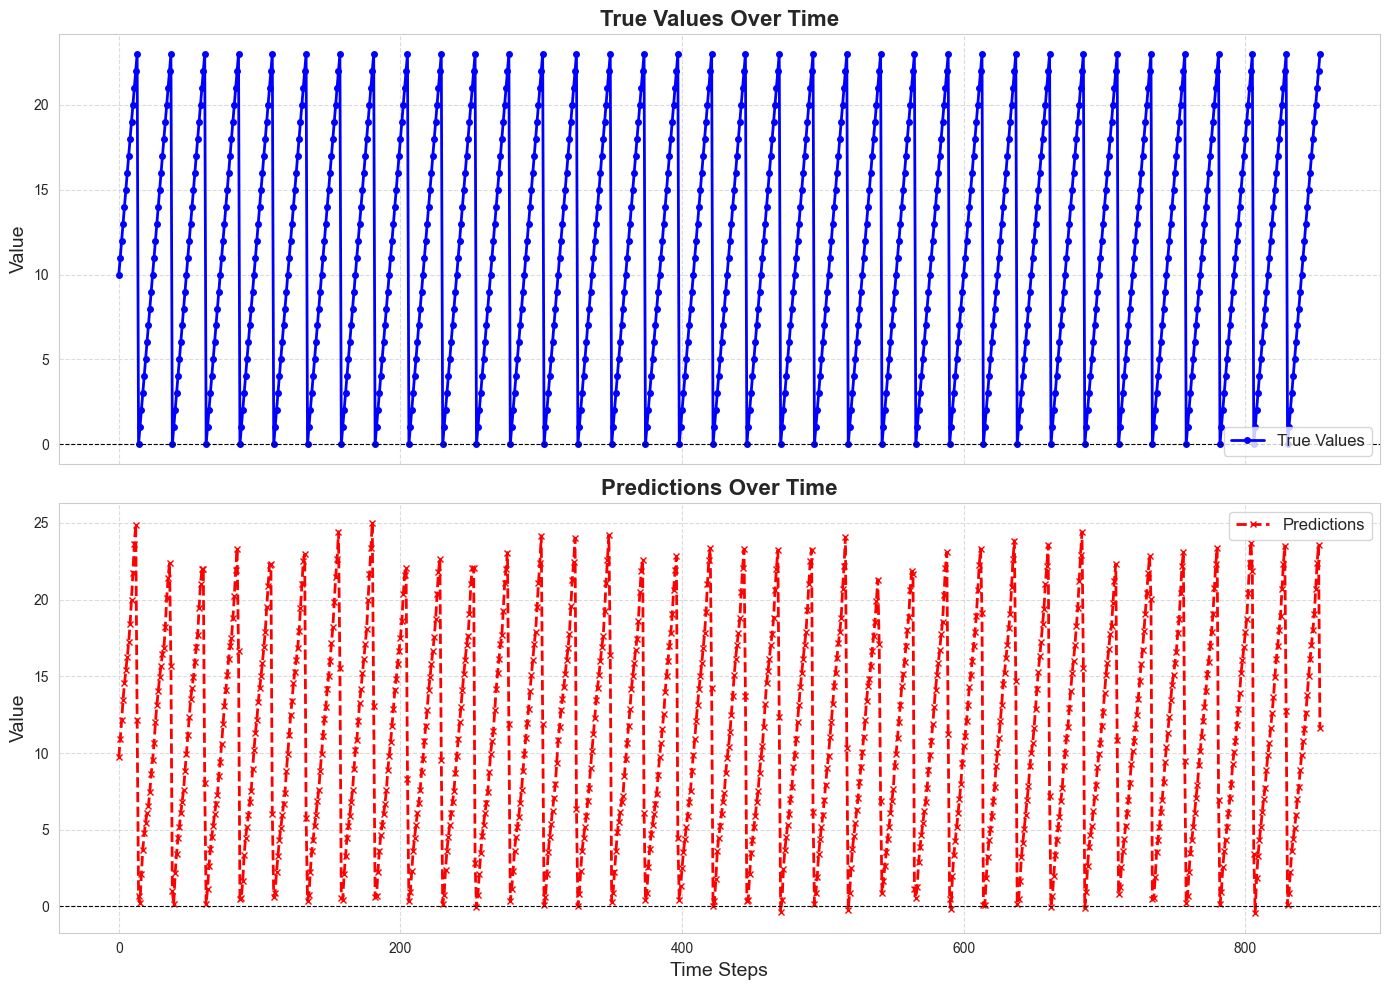

In [109]:
# Create a time array
time_steps = np.arange(len(y_test_inverse))

# Create a figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot True Values
axs[0].plot(time_steps, y_test_inverse, label='True Values', color='blue', linestyle='-', linewidth=2, marker='o', markersize=4)
axs[0].set_title('True Values Over Time', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Value', fontsize=14)
axs[0].legend(fontsize=12)
axs[0].grid(visible=True, linestyle='--', alpha=0.7)

# Plot Predictions
axs[1].plot(time_steps, y_pred_inverse, label='Predictions', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
axs[1].set_title('Predictions Over Time', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Time Steps', fontsize=14)
axs[1].set_ylabel('Value', fontsize=14)
axs[1].legend(fontsize=12)
axs[1].grid(visible=True, linestyle='--', alpha=0.7)

# Add a reference horizontal line at y=0
for ax in axs:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Improve spacing
plt.tight_layout()
plt.show()

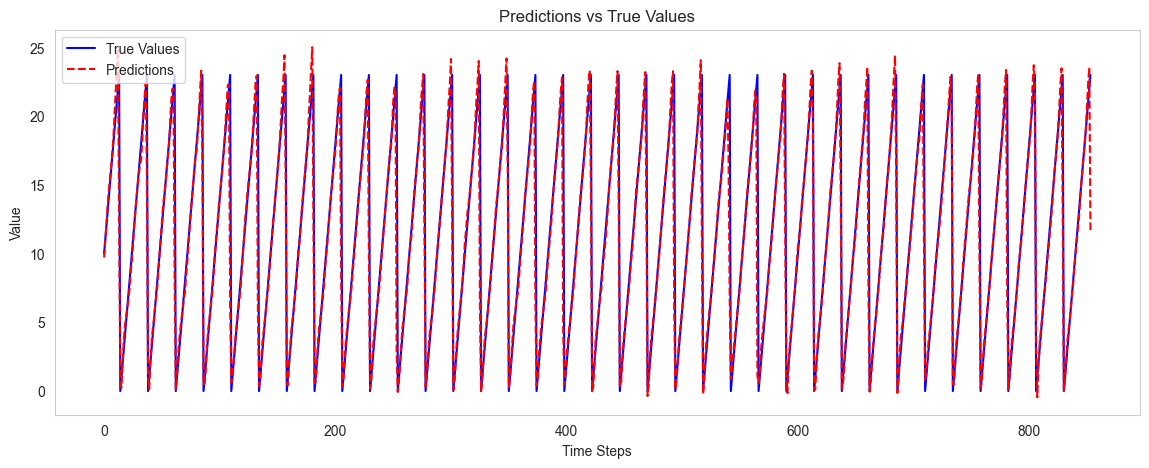

In [111]:
# Plot Predictions vs True Values
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test_inverse, label='True Values', color='blue')
plt.plot(y_pred_inverse, label='Predictions', color='red', linestyle="dashed")
plt.title('Predictions vs True Values')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

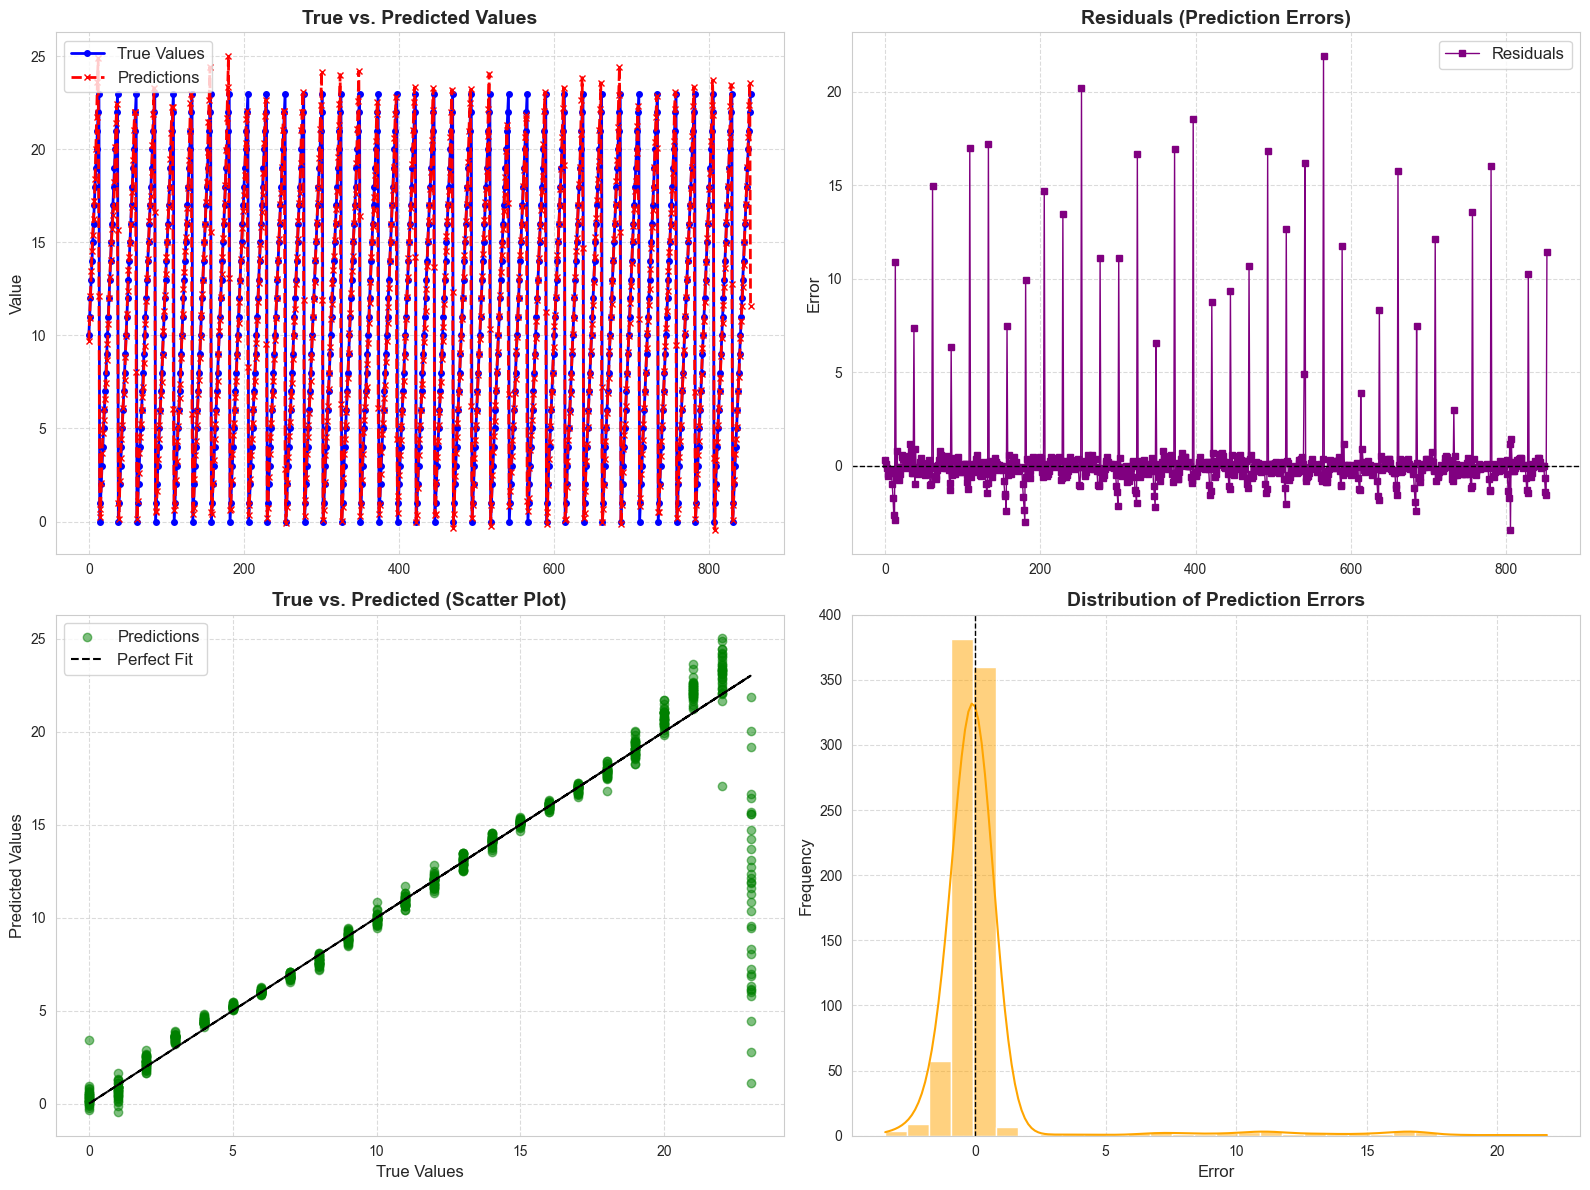

In [115]:
# y_test_inverse = ...  # True values after inverse transformation
# y_pred_inverse = ...  # Predicted values after inverse transformation

time_steps = np.arange(len(y_test_inverse))  # Create a time array

# Create a figure with 4 subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: True vs. Predicted Values (Line Plot)
axs[0, 0].plot(time_steps, y_test_inverse, label='True Values', color='blue', linestyle='-', linewidth=2, marker='o', markersize=4)
axs[0, 0].plot(time_steps, y_pred_inverse, label='Predictions', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
axs[0, 0].set_title('True vs. Predicted Values', fontsize=14, fontweight='bold')
axs[0, 0].set_ylabel('Value', fontsize=12)
axs[0, 0].legend(fontsize=12)
axs[0, 0].grid(visible=True, linestyle='--', alpha=0.7)

# Plot 2: Residual Plot (Errors)
residuals = y_test_inverse - y_pred_inverse
axs[0, 1].plot(time_steps, residuals, label='Residuals', color='purple', linestyle='-', linewidth=1, marker='s', markersize=4)
axs[0, 1].axhline(0, color='black', linewidth=1, linestyle='--')
axs[0, 1].set_title('Residuals (Prediction Errors)', fontsize=14, fontweight='bold')
axs[0, 1].set_ylabel('Error', fontsize=12)
axs[0, 1].legend(fontsize=12)
axs[0, 1].grid(visible=True, linestyle='--', alpha=0.7)

# Plot 3: Scatter Plot of True vs. Predicted Values
axs[1, 0].scatter(y_test_inverse, y_pred_inverse, color='green', alpha=0.5, label='Predictions')
axs[1, 0].plot(y_test_inverse, y_test_inverse, color='black', linestyle='--', label='Perfect Fit')  # Reference line
axs[1, 0].set_title('True vs. Predicted (Scatter Plot)', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('True Values', fontsize=12)
axs[1, 0].set_ylabel('Predicted Values', fontsize=12)
axs[1, 0].legend(fontsize=12)
axs[1, 0].grid(visible=True, linestyle='--', alpha=0.7)

# Plot 4: Histogram of Residuals
sns.histplot(residuals, bins=30, kde=True, color='orange', ax=axs[1, 1])
axs[1, 1].axvline(0, color='black', linewidth=1, linestyle='--')
axs[1, 1].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Error', fontsize=12)
axs[1, 1].set_ylabel('Frequency', fontsize=12)
axs[1, 1].grid(visible=True, linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()